# 🚀 Pipeline ALPR Ligero Orientado a Eventos (Vía de Lastre - Pintag)
**Arquitectura:** Crop Físico + Motion Gate 3 Estados + YOLOv8 + ByteTrack + Top-M/Top-K + FastPlateOCR + Deduplicación + Reporte Excel con Fotos Incrustadas.

> **Aceleración GPU:** Asegúrate de que el entorno de ejecución tenga una GPU asignada:
>  →  → .

In [1]:
# 1. Verificar GPU NVIDIA disponible en Colab
!nvidia-smi

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Thu Sep 17 17:06:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Instalar dependencias con soporte CUDA 12 para Google Colab
!pip install -q opencv-python-headless numpy openpyxl pillow pyyaml supervision ultralytics
!pip install -q fast-alpr

# Evitar conflicto de CUDA 13 en Colab fijando onnxruntime-gpu compatible con CUDA 12:
!pip uninstall -y -q onnxruntime onnxruntime-gpu
!pip install -q "onnxruntime-gpu==1.22.0"

import onnxruntime as ort
print(f"✅ ONNX Runtime: {ort.__version__}")
print(f"✅ Proveedores ONNX disponibles: {ort.get_available_providers()}")


✅ ONNX Runtime: 1.22.0
✅ Proveedores ONNX disponibles: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [3]:
# 3. Montar Google Drive y localizar videos
import os
import glob

from google.colab import drive
drive.mount("/content/drive")

# Clonar o actualizar el repositorio con git pull
if not os.path.exists("/content/PlacasVideos"):
    !git clone https://github.com/riofutabac/PlacasVideos.git /content/PlacasVideos
    %cd /content/PlacasVideos
else:
    %cd /content/PlacasVideos
    !git pull

print(f"✅ Proyecto activo: {os.getcwd()}")

# ==========================================================
# RUTA A LA CARPETA DE VIDEOS EN GOOGLE DRIVE
# ==========================================================
VIDEOS_DIR = "/content/drive/MyDrive/Cam PL"

# Buscar todos los MP4, incluso dentro de subcarpetas
videos = glob.glob(
    os.path.join(VIDEOS_DIR, "**", "*.mp4"),
    recursive=True
)

print(f"📂 Carpeta de videos: {VIDEOS_DIR}")
print(f"📹 Videos encontrados: {len(videos)}")

for video in videos[:10]:
    print(" -", video)

if not videos:
    print("❌ No se encontraron archivos MP4. Revisa la ruta.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/PlacasVideos
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 869 bytes | 869.00 KiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   46cfb8a..674aaa9  main       -> origin/main
Updating 46cfb8a..674aaa9
Fast-forward
 main.py | 30 +++++++++++++++++++++++++++++-
 1 file changed, 29 insertions(+), 1 deletion(-)
✅ Proyecto activo: /content/PlacasVideos
📂 Carpeta de videos: /content/drive/MyDrive/Cam PL
📹 Videos encontrados: 63
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038.mp4
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(1).mp4
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-202609091

In [5]:
# 4. Ejecutar el Benchmark Controlado en Clips (60) y (61) con NVDEC
# Por defecto usa backend "auto" (detecta NVIDIA NVDEC por hardware):
!python main.py "$VIDEOS_DIR" --clips 60 61

# Para prueba A/B contra el baseline CPU (OpenCV):
# !python main.py "$VIDEOS_DIR" --clips 60 61 --decoder opencv

# Para procesar TODOS los videos de la carpeta con NVDEC:
# !python main.py "$VIDEOS_DIR"


PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.2.0
Inicio de corrida: 2026-09-17 17:11:05
📹 Videos a procesar (10 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(1).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(2).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(3).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(4).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(5).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(6).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(7).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(8).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(9).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(10).mp4
Loading

In [8]:
# 5. Visualizar la Telemetría Almacenada en SQLite
import sqlite3
import pandas as pd

conn = sqlite3.connect("data/events.sqlite")
print("=== ÚLTIMA CORRIDA ===")
display(pd.read_sql("SELECT run_id, total_videos, total_events, speed_ratio, started_at, finished_at FROM processing_runs ORDER BY rowid DESC LIMIT 1", conn))

print("=== TELEMETRÍa POR CLIP ===")
display(pd.read_sql("SELECT clip_id, wall_clock_seconds, speed_ratio, decode_seconds, vehicle_detection_seconds, processed_events FROM processed_clips ORDER BY rowid DESC LIMIT 2", conn))

print("=== EVENTOS DETECTADOS ===")
display(pd.read_sql("SELECT event_id, datetime_str, direction, vehicle_type, plate_raw, plate_corrected, plate_status, duplicate_of FROM events ORDER BY rowid DESC LIMIT 10", conn))
conn.close()

=== ÚLTIMA CORRIDA ===


,run_id,total_videos,total_events,speed_ratio,started_at,finished_at
0,RUN_20260917_171108,10,21,1.69,2026-09-17 17:11:08,2026-09-17 17:37:28


=== TELEMETRÍa POR CLIP ===


,clip_id,wall_clock_seconds,speed_ratio,decode_seconds,vehicle_detection_seconds,processed_events
0,Camara Placas 2_20260909105651-20260909163038(...,195.73,1.68,176.677,14.098,4
1,Camara Placas 2_20260909105651-20260909163038(...,189.80,1.74,174.436,12.111,4


=== EVENTOS DETECTADOS ===


,event_id,datetime_str,direction,vehicle_type,plate_raw,plate_corrected,plate_status,duplicate_of
0,EVT_(10)_0045_113,2026-09-09 11:48:23,ENTRADA,truck,PBQ6754,PBQ6754,OK,EVT_(10)_0044_112
1,EVT_(10)_0044_112,2026-09-09 11:48:22,ENTRADA,truck,PBQ6758,PBQ6758,OK,None
2,EVT_(10)_0019_32,2026-09-09 11:47:02,ENTRADA,truck,ABM6665,ABM6665,OK,None
3,EVT_(10)_0005_0,2026-09-09 11:46:30,ENTRADA,bus,PCX6575,PCX6575,OK,None
4,EVT_8(9)_0062_198,2026-09-09 11:44:23,ENTRADA,motorcycle,None,None,PLACA_NO_DETECTADA,None
5,EVT_8(9)_0051_128,2026-09-09 11:43:13,SALIDA,motorcycle,None,None,PLACA_NO_DETECTADA,None
6,EVT_8(9)_0038_88,2026-09-09 11:42:33,ENTRADA,truck,PFU3047,PFU3047,OK,None
7,EVT_8(9)_0010_21,2026-09-09 11:41:26,SALIDA,car,PPA8556,PPA8556,OK,None
8,EVT_8(7)_0028_292,2026-09-09 11:35:07,ENTRADA,car,PBU9320,PBU9320,OK,None
9,EVT_8(7)_0011_132,2026-09-09 11:32:27,ENTRADA,truck,PAC7437,PAC7437,OK,None


Total fotos de vehículos guardadas: 21
Evidencia: evidence/vehicles/EVT_(10)_0005_0_veh.jpg


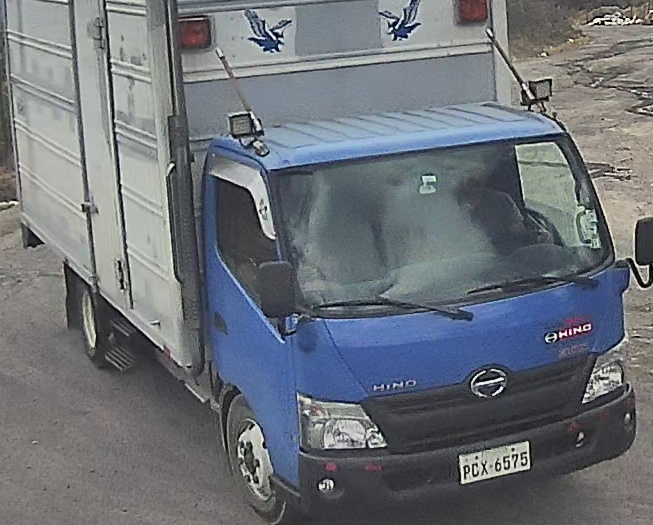

Evidencia: evidence/vehicles/EVT_(10)_0019_32_veh.jpg


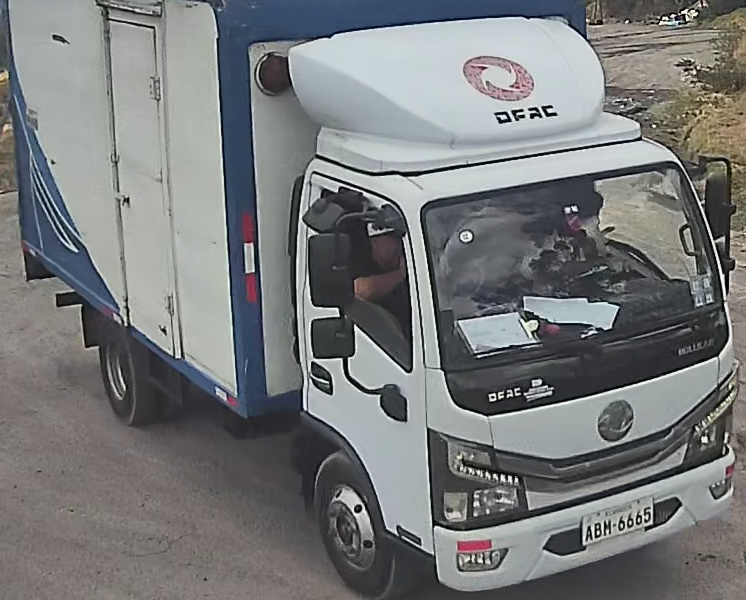

Evidencia: evidence/vehicles/EVT_(10)_0044_112_veh.jpg


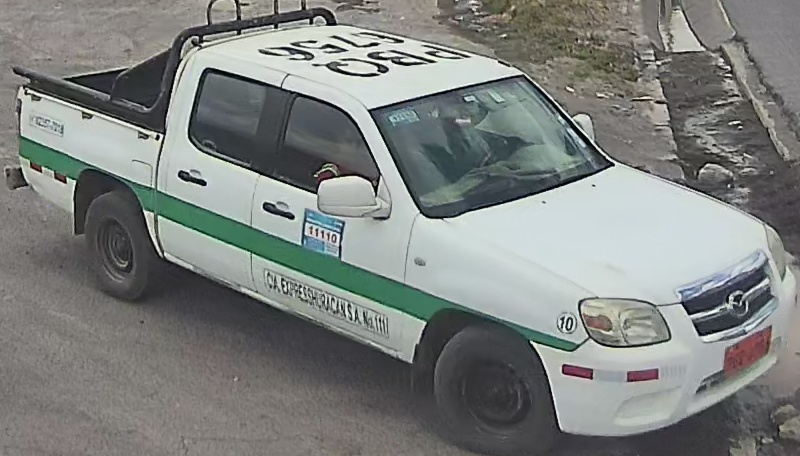

Evidencia: evidence/vehicles/EVT_(10)_0045_113_veh.jpg


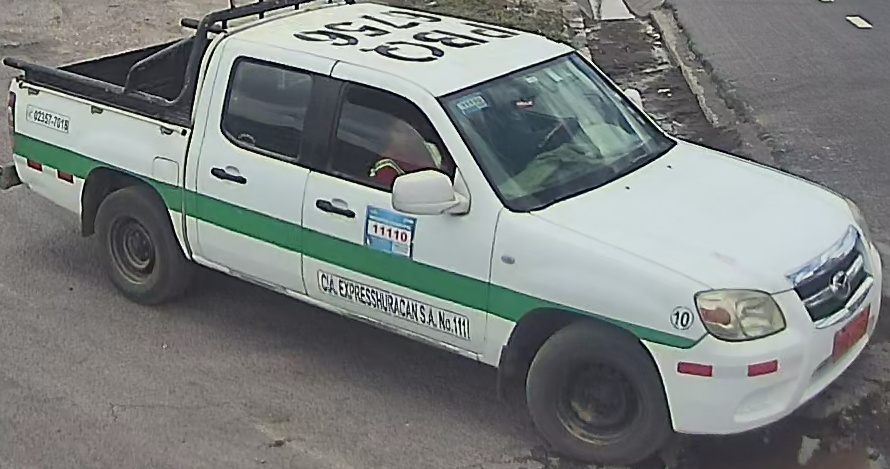

In [9]:
# 6. Galería de Evidencias (Fotos de Vehículos y Recortes de Placa)
import glob
from IPython.display import Image, display

veh_images = sorted(glob.glob("evidence/vehicles/*.jpg"))
print(f"Total fotos de vehículos guardadas: {len(veh_images)}")
for img_path in veh_images[:4]:
    print(f"Evidencia: {img_path}")
    display(Image(filename=img_path, width=400))

In [ ]:
# 7. Descargar el Reporte Excel de Auditoría
try:
    from google.colab import files
    if os.path.exists("reports/reporte_auditoria.xlsx"):
        files.download("reports/reporte_auditoria.xlsx")
        print("📥 Descargando reporte_auditoria.xlsx...")
except Exception as e:
    print(f"Descarga manual disponible en reports/reporte_auditoria.xlsx: {e}")

In [15]:

    # 1. Comprobar capacidades de GPU y decodificadores disponibles en Colab
    !nvidia-smi
    !ffmpeg -hide_banner -hwaccels
    !ffmpeg -hide_banner -decoders | grep -Ei "h264_cuvid|hevc_cuvid|nvdec|cuvid"

    # 2. Copiar localmente el clip 60 para el benchmark puro
    import os, shutil
    os.makedirs("/content/videos_local", exist_ok=True)
    src_60 = "/content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(60).mp4"
    dst_60 = "/content/videos_local/clip_60.mp4"
    if not os.path.exists(dst_60):
        shutil.copyfile(src_60, dst_60)
        print("✅ Clip 60 copiado a local.")

    # 3. Metadatos del códec
    !ffprobe -v error -select_streams v:0 -show_entries stream=codec_name,width,height,r_frame_rate,pix_fmt -of default=noprint_wrappers=1 /content/videos_local/clip_60.mp4

    # 4. BENCHMARK A: Decodificación CPU pura con FFmpeg
    print("\n--- BENCHMARK 1: CPU Decode ---")
    !ffmpeg -benchmark -v error -c:v hevc -i /content/videos_local/clip_60.mp4 -map 0:v:0 -f null -

    # 5. BENCHMARK B: Decodificación por Hardware GPU (CUDA/NVDEC)
    print("\n--- BENCHMARK 2: NVDEC CUDA Hardware Decode ---")
    !ffmpeg -benchmark -v error -hwaccel cuda -hwaccel_output_format cuda -i \
  /content/videos_local/clip_60.mp4 -map 0:v:0 -f null -

    # 6. BENCHMARK C: Decodificación explícita CUVID
    print("\n--- BENCHMARK 3: CUVID Decode ---")
    !ffmpeg -benchmark -v error -c:v hevc_cuvid -i /content/videos_local/clip_60.mp4 -map 0:v:0 -\
  f null -


Thu Sep 17 17:46:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
import subprocess
import time

VIDEO = "/content/videos_local/clip_60.mp4"

def benchmark(name, cmd):
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    t0 = time.perf_counter()

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    elapsed = time.perf_counter() - t0

    print(f"Return code: {result.returncode}")
    print(f"WALL TIME: {elapsed:.3f} s")

    if result.returncode != 0:
        print("\n--- STDERR ---")
        print(result.stderr[-4000:])

    return elapsed


# ============================================================
# A) FFmpeg CPU HEVC decode
# ============================================================

cpu_time = benchmark(
    "1. CPU — HEVC software decode",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-f", "null",
        "-"
    ]
)


# ============================================================
# B) NVDEC automático vía CUDA
# Mantiene los frames en GPU
# ============================================================

nvdec_time = benchmark(
    "2. NVIDIA NVDEC — CUDA hwaccel",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-hwaccel", "cuda",
        "-hwaccel_output_format", "cuda",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-f", "null",
        "-"
    ]
)


# ============================================================
# C) Decoder HEVC CUVID explícito
# ============================================================

cuvid_time = benchmark(
    "3. NVIDIA HEVC_CUVID",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-c:v", "hevc_cuvid",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-f", "null",
        "-"
    ]
)


print("\n" + "=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"CPU:          {cpu_time:8.3f} s")
print(f"CUDA NVDEC:   {nvdec_time:8.3f} s")
print(f"HEVC CUVID:   {cuvid_time:8.3f} s")

if nvdec_time > 0:
    print(f"Speedup NVDEC vs CPU: {cpu_time/nvdec_time:.2f}x")

if cuvid_time > 0:
    print(f"Speedup CUVID vs CPU: {cpu_time/cuvid_time:.2f}x")


1. CPU — HEVC software decode
Return code: 0
WALL TIME: 164.057 s

2. NVIDIA NVDEC — CUDA hwaccel
Return code: 0
WALL TIME: 14.685 s

3. NVIDIA HEVC_CUVID
Return code: 0
WALL TIME: 21.132 s

RESULTADOS
CPU:           164.057 s
CUDA NVDEC:     14.685 s
HEVC CUVID:     21.132 s
Speedup NVDEC vs CPU: 11.17x
Speedup CUVID vs CPU: 7.76x


In [17]:
download_time = benchmark(
    "4. NVDEC + transferencia GPU → CPU",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-hwaccel", "cuda",
        "-hwaccel_output_format", "cuda",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-vf", "hwdownload,format=nv12",
        "-f", "null",
        "-"
    ]
)

print(f"NVDEC + GPU→CPU: {download_time:.3f} s")


4. NVDEC + transferencia GPU → CPU
Return code: 0
WALL TIME: 21.697 s
NVDEC + GPU→CPU: 21.697 s
